In [ ]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

# Các mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [ ]:
# Load dataset from Hugging Face
dataset = load_dataset("usernone1234/capstone-llm-project-SP26AI20")
df = pd.DataFrame(dataset['train'])
df.head

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/354 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10909 [00:00<?, ? examples/s]

<bound method NDFrame.head of                                               user_query    Emotion  \
0      Mình vừa tham gia một buổi tư vấn sức khỏe tâm...     Vui vẻ   
1      Em mệt với việc lúc nào cũng bị so sánh điểm v...  Chán ghét   
2      Em thấy mình quá chậm chạp khi bắt đầu học một...      Lo âu   
3                                Ai sẽ đón em chiều nay?      Other   
4                                 Ai sẽ nấu cơm tối nay?      Other   
...                                                  ...        ...   
10904  mình là một đứa sắp bước đến cuộc thi quan trọ...      Lo âu   
10905  tớ đã thích cậu 2 năm rồi. chúng ta học cùng l...    Buồn bã   
10906  Tôi Hải Đăng xin mở lời nói lên cảm xúc của ch...   Lạc quan   
10907  Mình là một người ít nói, ng hướng nội, cx hay...   Lạc quan   
10908  Những người con xa xứ. Chúng tôi đang ở một nơ...   Lạc quan   

                                                response  
0      Thật hạnh phúc khi bạn đã tìm thấy một không g...  
1      Sự mệt mỏi của bạn là rất dễ hiểu. So sánh liê...  
2      Mỗi người có một nhịp độ tiếp thu khác nhau và...  
3      Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...  
4      Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...  
...                                                  ...  
10904  Cần rất nhiều can đảm để chia sẻ những cảm xúc...  
10905  Nghe có vẻ như bạn đang phải gánh chịu một gán...  
10906  Cần rất nhiều can đảm để chia sẻ những cảm xúc...  
10907  Nghe có vẻ như bạn đã trải qua một trải nghiệm...  
10908  Việc bạn vẫn luôn hướng về quê hương, đau cùng...  

[10909 rows x 3 columns]>

In [ ]:
print(df.head(5))

                                          user_query    Emotion  \
0  Mình vừa tham gia một buổi tư vấn sức khỏe tâm...     Vui vẻ   
1  Em mệt với việc lúc nào cũng bị so sánh điểm v...  Chán ghét   
2  Em thấy mình quá chậm chạp khi bắt đầu học một...      Lo âu   
3                            Ai sẽ đón em chiều nay?      Other   
4                             Ai sẽ nấu cơm tối nay?      Other   

                                            response  
0  Thật hạnh phúc khi bạn đã tìm thấy một không g...  
1  Sự mệt mỏi của bạn là rất dễ hiểu. So sánh liê...  
2  Mỗi người có một nhịp độ tiếp thu khác nhau và...  
3  Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...  
4  Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...  


emotion_groupped
Sadness            2685
Positive           2543
Anxiety_Fear       1787
Neutral            1561
Anger              1559
Highly_Negative     774
Name: count, dtype: int64


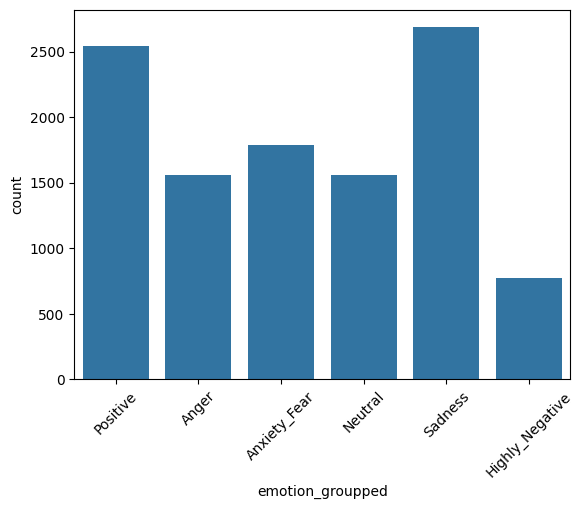

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
label_groups = {
    'Buồn bã': 'Negative_Sad',
    'Chán ghét': 'Negative_Sad',
    'Cô đơn': 'Negative_Sad',
    'Hối tiếc': 'Negative_Sad',
    'Lo âu': 'Negative_Sad',
    'Highly negative': 'Negative_Sad',
    'Vui vẻ': 'Positive',
    'Lạc quan': 'Positive',
    'Ngạc nhiên': 'Surprise',
    'Tức giận': 'Anger',
    'Sợ hãi': 'Fear',
    'Trung lập': 'Neutral_Other',
    'Other': 'Neutral_Other'
}

# label_groups = {
#     # sadness cluster
#     'Buồn bã': 'Sadness',
#     'Cô đơn': 'Sadness',
#     'Hối tiếc': 'Sadness',

#     # anxiety / fear cluster
#     'Lo âu': 'Anxiety_Fear',
#     'Sợ hãi': 'Anxiety_Fear',

#     # anger cluster
#     'Tức giận': 'Anger',
#     'Chán ghét': 'Anger',

#     # positive
#     'Vui vẻ': 'Positive',
#     'Lạc quan': 'Positive',
#     'Ngạc nhiên': 'Positive',

#     # neutral
#     'Trung lập': 'Neutral',
#     'Other': 'Neutral',

#     # highly neg
#     'Highly negative': 'Highly_Negative'
# }

df["emotion_groupped"] = df["Emotion"].map(label_groups)

# Visualize it
print(df['emotion_groupped'].value_counts())
sns.countplot(x='emotion_groupped', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
import re
import pandas as pd

teencode_dict = {
    "ctrai": "con trai", "khôg": "không", "bme": "bố mẹ", "cta": "chúng ta",
    "mih": "mình", "mqh": "mối quan hệ", "cgai": "con gái", "nhữg": "những",
    "mng": "mọi người", "svtn": "sinh viên tình nguyện", "qtam": "quan tâm",
    "thươg": "thương", "qtâm": "quan tâm", "chug": "chung", "trườg": "trường",
    "thoy": "thôi", "đki": "đăng ký", "atsm": "ảo tưởng sức mạnh", "ạk": "ạ",
    "vch": "vãi chưởng", "cùg": "cùng", "pn": "bạn", "pjt": "biết",
    "thjk": "thích", "keke": "ce ce", "ktra": "kiểm tra", "nek": "nè",
    "cgái": "con gái", "nthe": "như thế", "chúg": "chúng", "kái": "cái",
    "tìh": "tình", "phòg": "phòng", "lòg": "lòng", "từg": "từng",
    "rằg": "rằng", "sốg": "sống", "thuj": "thôi", "thuơng": "thương",
    "càg": "càng", "đky": "đăng ký", "bằg": "bằng", "sviên": "sinh viên",
    "ák": "á", "đág": "đáng", "nvay": "như vậy", "nhjeu": "nhiều",
    "xg": "xuống", "zồi": "rồi", "trag": "trang", "zữ": "dữ",
    "atrai": "anh trai", "kte": "kinh tế", "độg": "động", "lmht": "liên minh huyền thoại",
    "gắg": "gắng", "đzai": "đẹp trai", "thgian": "thời gian", "plz": "pờ ly",
    "đồg": "đồng", "btrai": "bạn trai", "nthê": "như thế", "hìhì": "hì hì",
    "vọg": "vọng", "hihe": "hi he", "đôg": "đông", "răg": "răng",
    "thườg": "thường", "tcảm": "tình cảm", "đứg": "đứng", "ksao": "không sao",
    "dz": "đẹp trai", "hjxhjx": "hix hix", "cmày": "chúng mày", "xuốg": "xuống",
    "nkư": "như", "lquan": "liên quan", "tiếg": "tiếng", "hajz": "hai",
    "xih": "xinh", "hìh": "hình", "thàh": "thành", "ngke": "nghe",
    "dzậy": "dậy", "teencode": "tin cốt", "tnào": "thế nào", "tưởg": "tưởng",
    "ctrinh": "chương trình", "phog": "phong", "hôg": "không", "zìa": "gì",
    "kũg": "cũng", "ntnao": "như thế nào", "trọg": "trọng", "nthế": "như thế",
    "năg": "năng",
    "ngđó": "người đó", "lquen": "làm quen", "riêg": "riêng",
    "ngag": "ngang", "hêhê": "hê hê", "bnhiu": "bao nhiêu", "ngốk": "ngốc",
    "kậu": "cậu", "highland": "hai lừn", "kqua": "kết quả", "htrc": "hôm trước",
    "địh": "định", "gđình": "gia đinh", "giốg": "giống", "csống": "cuộc sống",
    "xug": "xùng", "zùi": "rồi", "bnhiêu": "bao nhiêu", "cbị": "chuẩn bị",
    "kòn": "còn", "buôg": "buông", "csong": "cuộc sống", "chàg": "chàng",
    "chăg": "chăng", "ngàh": "ngành", "llac": "liên lạc", "nkưng": "nhưng",
    "nắg": "nắng", "tíh": "tính", "khoảg": "khoảng", "thík": "thích",
    "ngđo": "người đó", "ngkhác": "người khác", "thẳg": "thẳng", "kảm": "cảm",
    "dàh": "dành", "júp": "giúp", "lặg": "lặng", "vđê": "vấn đề",
    "bbè": "bạn bè", "bóg": "bóng", "dky": "đăng ký", "dòg": "dòng",
    "uốg": "uống", "tyêu": "tình yêu", "snvv": "sinh nhật vui vẻ", "đthoại": "điện thoại",
    "qhe": "quan hệ", "cviec": "công việc", "tượg": "tượng", "qà": "quà",
    "thjc": "thích", "nhưq": "nhưng", "cđời": "cuộc đời", "bthường": "bình thường",
    "zà": "già", "đáh": "đánh", "xloi": "xin lỗi", "zám": "dám",
    "qtrọng": "quan trọng", "bìh": "bình", "lzi": "làm gì", "qhệ": "quan hệ",
    "đhbkhn": "đại học bách khoa hà nội", "hajzz": "hai", "kủa": "của", "lz": "làm gì",
    "đhkhtn": "đại học khoa học tự nhiên", "đóg": "đóng", "cka": "cha", "lgi": "làm gì",
    "nvậy": "như vậy", "qả": "quả", "đkiện": "điều kiện", "nèk": "nè",
    "tlai": "tương lai", "bsĩ": "bác sĩ", "hkì": "học kỳ", "đcsvn": "đảng cộng sản việt nam",
    "vde": "vấn đề", "chta": "chúng ta", "òy": "rồi", "ltinh": "linh tinh",
    "ngyeu": "người yêu", "đthoai": "điện thoại", "snghĩ": "suy nghĩ", "nặg": "nặng",
    "họk": "học", "dừg": "dừng", "hphúc": "hạnh phúc", "hiha": "hi ha",
    "wtâm": "quan tâm", "thíck": "thích", "chuện": "chuyện", "lạh": "lạnh",
    "fây": "phây", "ntnày": "như thế này", "lúk": "lúc", "haj": "hai",
    "ngía": "nghía", "mớj": "mới", "hsơ": "hồ sơ", "ctraj": "con trai",
    "nyêu": "người yêu", "điiiiiii": "đi", "rồii": "rồi", "kb": "kết bạn",
    "hixxx": "hích", "dthương": "dễ thương", "nhiềuuu": "nhiều", "ctrình": "chương trình",
    "mìnk": "mình", "mjh": "mình", "ng": "người", "vc": "vợ chồng",
    "uhm": "ừm", "thỳ": "thì", "nyc": "người yêu cũ", "nàg": "nàng",
    "thôii": "thôi", "đjên": "điên", "bgái": "bạn gái", "vớii": "với",
    "xink": "xinh", "hđộng": "hành động", "đhọc": "đại học", "mk": "mình",
    "bn": "bạn", "thik": "thích", "cj": "chị", "mn": "mọi người",
    "nguoi": "người", "nógn": "nóng", "hok": "không", "ko": "không",
    "bik": "biết", "vs": "với", "cx": "cũng", "mik": "mình",
    "wtf": "what the fuck", "đc": "được", "cmt": "comment", "ck": "chồng",
    "chk": "chồng", "ngta": "người ta", "gđ": "gia đình", "oh": "ồ",
    "vk": "vợ", "ctác": "công tác", "sg": "sài gòn", "ae": "anh em",
    "ah": "à", "ạh": "ạ", "rì": "gì", "ms": "mới",
    "vn": "việt nam", "nhaa": "nha", "cũg": "cũng", "đag": "đang",
    "ơiii": "ơi", "hic": "hích", "ace": "anh chị em", "àk": "à",
    "uh": "ừ", "cmm": "con mẹ mày", "cmnr": "con mẹ nó rồi", "ơiiii": "ơi",
    "hnay": "hôm nay", "ukm": "ừm", "tq": "trung quốc", "ctr": "chương trình",
    "đii": "đi", "nch": "nói chuyện", "trieu": "triệu", "hahah": "ha ha",
    "nta": "người ta", "ngèo": "nghèo", "kêh": "kênh", "ak": "à",
    "ad": "admin", "j": "gì", "ny": "người yêu", "dc": "được",
    "qc": "quảng cáo", "baoh": "bao giờ", "zui": "vui", "zẻ": "vẻ",
    "tym": "tim", "aye": "anh yêu em", "eya": "em yêu anh", "fb": "facebook",
    "insta": "instagram", "z": "vậy", "thich": "thích", "vcl": "vờ cờ lờ",
    "đt": "điện thoại", "acc": "account", "lol": "lồn", "loz": "lồn",
    "lozz": "lồn", "trc": "trước", "chs": "chẳng hiểu sao", "đhs": "đéo hiểu sao",
    "qá": "quá", "ntn": "như thế nào", "wá": "quá", "zậy": "vậy",
    "zô": "vô", "ytb": "youtube", "vđ": "vãi đái", "vchg": "vãi chưởng",
    "sml": "sấp mặt lờ", "xl": "xin lỗi", "cmn": "con mẹ nó", "face": "facebook",
    "hjhj": "hi hi", "vv": "vui vẻ", "ns": "nói", "iu": "yêu",
    "vcđ": "vãi cải đái", "in4": "info", "qq": "quằn què", "sub": "subcribe",
    "kh": "không", "zạ": "vậy", "oy": "rồi", "jo": "giờ",
    "clmm": "cái lồn mẹ mày", "bsvv": "buổi sáng vui vẻ", "troai": "trai", "wa": "quá",
    "hjx": "hix", "e": "em", "ik": "ý", "ji": "gì",
    "ce": "chị em", "lm": "làm", "đz": "đẹp giai", "sr": "sorry",
    "ib": "inbox", "hoy": "thôi", "đbh": "đéo bao giờ", "k": "không",
    "vd": "ví dụ", "a": "anh", "unf": "unfriend", "my fen": "my friend",
    "fen": "friend", "cty": "công ty", "on lai": "online", "u hai ba": "u23",
    "kô": "không", "đtqg": "đội tuyển quốc gia", "hqua": "hôm qua", "xog": "xong",
    "uk": "ừ", "nhoé": "nhé", "biet": "biết", "quí": "quý",
    "stk": "số tài khoản", "hong kong": "hồng kông", "đươc": "được", "nghành": "ngành",
    "nvqs": "nghĩa vụ quân sự", "ngừoi": "người", "trog": "trong", "tgian": "thời gian",
    "biêt": "biết", "fải": "phải", "nguời": "người", "tđn": "thế đéo nào",
    "bth": "bình thường", "tgdd": "thế giới di động", "khg": "không", "nhưg": "nhưng",
    "thpt": "trung học phổ thông", "thằg": "thằng", "đuợc": "được", "ku": "cu",
    "thým": "thím", "onl": "online", "zú": "vú", "cmnd": "chứng minh nhân dân",
    "sđt": "số điện thoại", "klq": "không liên quan"
}


# Dấu hiệu Teencode (Ký tự lạ hoặc lặp âm)
teencode_re = r'[jzwf]|([a-z])\1{2,}|(vcl|vl|đcm|vãi|ô kê|uk|uh)'

def classify_query(text):
    text_lower = str(text).lower()
    if re.search(teencode_re, text_lower):
        return 'Teencode'
    if any(word in text_lower.split() for word in teencode_dict.keys()):
        return 'Abbreviation'
    if any(word in text_lower for word in ['trân trọng', 'quý khách', 'hài lòng', 'tuyệt vời']):
        return 'Premium'
    return 'Standard'

df['classify_query'] = df['user_query'].apply(classify_query)
print(df['classify_query'].value_counts())

classify_query
Standard        10200
Abbreviation      501
Teencode          142
Premium            66
Name: count, dtype: int64


In [ ]:
df

,user_query,Emotion,response,classify_query
0,Mình vừa tham gia một buổi tư vấn sức khỏe tâm...,Vui vẻ,Thật hạnh phúc khi bạn đã tìm thấy một không g...,Standard
1,Em mệt với việc lúc nào cũng bị so sánh điểm v...,Chán ghét,Sự mệt mỏi của bạn là rất dễ hiểu. So sánh liê...,Standard
2,Em thấy mình quá chậm chạp khi bắt đầu học một...,Lo âu,Mỗi người có một nhịp độ tiếp thu khác nhau và...,Standard
3,Ai sẽ đón em chiều nay?,Other,Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...,Standard
4,Ai sẽ nấu cơm tối nay?,Other,Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...,Standard
...,...,...,...,...
10904,mình là một đứa sắp bước đến cuộc thi quan trọ...,Lo âu,Cần rất nhiều can đảm để chia sẻ những cảm xúc...,Standard
10905,tớ đã thích cậu 2 năm rồi. chúng ta học cùng l...,Buồn bã,Nghe có vẻ như bạn đang phải gánh chịu một gán...,Abbreviation
10906,Tôi Hải Đăng xin mở lời nói lên cảm xúc của ch...,Lạc quan,Cần rất nhiều can đảm để chia sẻ những cảm xúc...,Standard
10907,"Mình là một người ít nói, ng hướng nội, cx hay...",Lạc quan,Nghe có vẻ như bạn đã trải qua một trải nghiệm...,Abbreviation


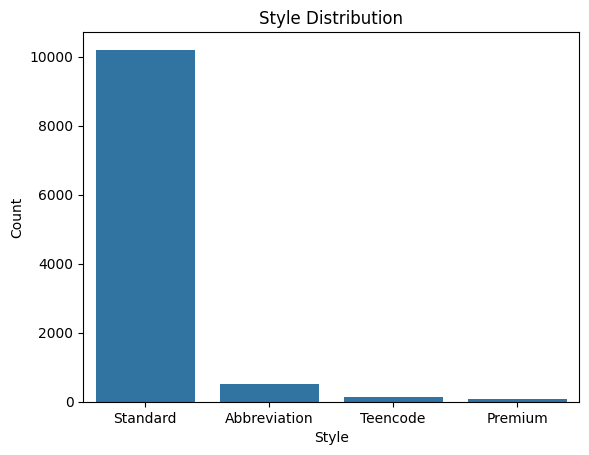

In [ ]:
# Draw the plot to visualize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the 'Style' column to a pandas Series before calling value_counts()
style_counts = df['classify_query'].value_counts()

# Create a bar plot

sns.barplot(x=style_counts.index, y=style_counts.values)
plt.title('Style Distribution')
plt.xlabel('Style')
plt.ylabel('Count')
plt.show()

In [ ]:
# Xử lý các từ viết tắt, teencode
!pip install underthesea
from underthesea import word_tokenize

def clean_vntk(text):
    # 1. Chuẩn hóa viết tắt & Teencode (Lớp 1)
    text = text.lower()
    words = text.split()
    words = [teencode_dict[w] if w in teencode_dict else w for w in words]
    text = " ".join(words)

    # 2. Xử lý dấu câu và ký tự đặc biệt (Lớp 2)
    # Giữ lại các dấu biểu cảm quan trọng như ! và ?
    text = re.sub(r'[\W_&&[^!?]]', ' ', text) # Keep ! and ?
    # Xử lý kéo dài: "hayyyy" -> "hay"
    text = re.sub(r'([a-z])\1{2,}', r'\1', text)

    # 3. Tách từ tiếng Việt (Lớp 3 - Quan trọng nhất cho Premium)
    # format="text" biến "hài lòng" thành "hài_lòng" giúp XGBoost hiểu là 1 cụm
    text = word_tokenize(text, format="text")

    return text

# Thực thi làm sạch
df['query_processed'] = df['user_query'].apply(clean_vntk)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.8 MB/s eta 0:00:00


/tmp/ipykernel_3743/3787398410.py:14: FutureWarning: Possible set intersection at position 4
  text = re.sub(r'[\W_&&[^!?]]', ' ', text) # Keep ! and ?


In [ ]:
df

,user_query,Emotion,response,classify_query,query_processed
0,Mình vừa tham gia một buổi tư vấn sức khỏe tâm...,Vui vẻ,Thật hạnh phúc khi bạn đã tìm thấy một không g...,Standard,mình vừa tham_gia một buổi tư_vấn sức khỏe tâm...
1,Em mệt với việc lúc nào cũng bị so sánh điểm v...,Chán ghét,Sự mệt mỏi của bạn là rất dễ hiểu. So sánh liê...,Standard,em mệt với việc lúc_nào cũng bị so_sánh điểm v...
2,Em thấy mình quá chậm chạp khi bắt đầu học một...,Lo âu,Mỗi người có một nhịp độ tiếp thu khác nhau và...,Standard,em thấy mình quá chậm_chạp khi bắt_đầu học một...
3,Ai sẽ đón em chiều nay?,Other,Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...,Standard,ai sẽ đón em chiều nay ?
4,Ai sẽ nấu cơm tối nay?,Other,Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...,Standard,ai sẽ nấu cơm tối nay ?
...,...,...,...,...,...
10904,mình là một đứa sắp bước đến cuộc thi quan trọ...,Lo âu,Cần rất nhiều can đảm để chia sẻ những cảm xúc...,Standard,mình là một đứa sắp bước đến cuộc thi quan_trọ...
10905,tớ đã thích cậu 2 năm rồi. chúng ta học cùng l...,Buồn bã,Nghe có vẻ như bạn đang phải gánh chịu một gán...,Abbreviation,tớ đã thích cậu 2 năm rồi . chúng_ta học cùng ...
10906,Tôi Hải Đăng xin mở lời nói lên cảm xúc của ch...,Lạc quan,Cần rất nhiều can đảm để chia sẻ những cảm xúc...,Standard,tôi hải_đăng xin mở lời_nói lên cảm_xúc của ch...
10907,"Mình là một người ít nói, ng hướng nội, cx hay...",Lạc quan,Nghe có vẻ như bạn đã trải qua một trải nghiệm...,Abbreviation,"mình là một người ít nói , người hướng nội , c..."


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Emotion_encoded'] = le.fit_transform(df['Emotion'])

tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X = tfidf.fit_transform(df['query_processed'])
y = df['Emotion_encoded']

X, y

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 233985 stored elements and shape (10909, 5000)>,
 0        12
 1         1
 2         5
 3         8
 4         8
          ..
 10904     5
 10905     0
 10906     6
 10907     6
 10908     6
 Name: Emotion_encoded, Length: 10909, dtype: int64)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Định nghĩa danh sách mô hình
# Lưu ý: Với văn bản, MultinomialNB thường hiệu quả hơn GaussianNB
models = {
    "Logistic Regression": LogisticRegression(),
    "Linear SVM": SVC(kernel='linear', probability=True),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}


--- Training Logistic Regression ---

Classification Report for Logistic Regression:
                 precision    recall  f1-score   support

        Buồn bã       0.42      0.58      0.48       219
      Chán ghét       0.72      0.64      0.68       160
         Cô đơn       0.71      0.71      0.71       164
Highly negative       0.66      0.52      0.58       137
       Hối tiếc       0.81      0.78      0.79       156
          Lo âu       0.49      0.51      0.50       187
       Lạc quan       0.59      0.66      0.62       197
     Ngạc nhiên       0.91      0.89      0.90       167
          Other       0.97      0.84      0.90       173
         Sợ hãi       0.84      0.76      0.80       168
      Trung lập       0.57      0.46      0.51       153
       Tức giận       0.86      0.87      0.87       154
         Vui vẻ       0.77      0.80      0.78       147

       accuracy                           0.69      2182
      macro avg       0.72      0.69      0.70      2182


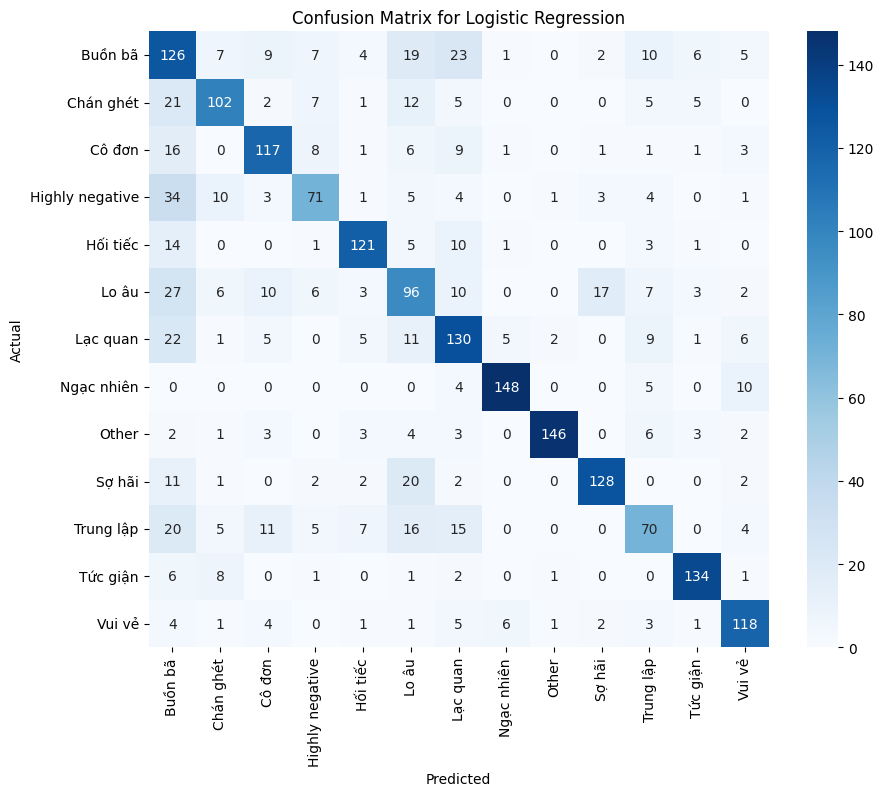


--- Training Linear SVM ---

Classification Report for Linear SVM:
                 precision    recall  f1-score   support

        Buồn bã       0.41      0.64      0.50       219
      Chán ghét       0.72      0.63      0.67       160
         Cô đơn       0.72      0.69      0.70       164
Highly negative       0.66      0.52      0.58       137
       Hối tiếc       0.83      0.74      0.79       156
          Lo âu       0.48      0.50      0.49       187
       Lạc quan       0.62      0.67      0.64       197
     Ngạc nhiên       0.93      0.85      0.89       167
          Other       0.97      0.87      0.92       173
         Sợ hãi       0.84      0.73      0.78       168
      Trung lập       0.55      0.50      0.52       153
       Tức giận       0.90      0.88      0.89       154
         Vui vẻ       0.84      0.79      0.81       147

       accuracy                           0.69      2182
      macro avg       0.73      0.69      0.71      2182
   weighted avg   

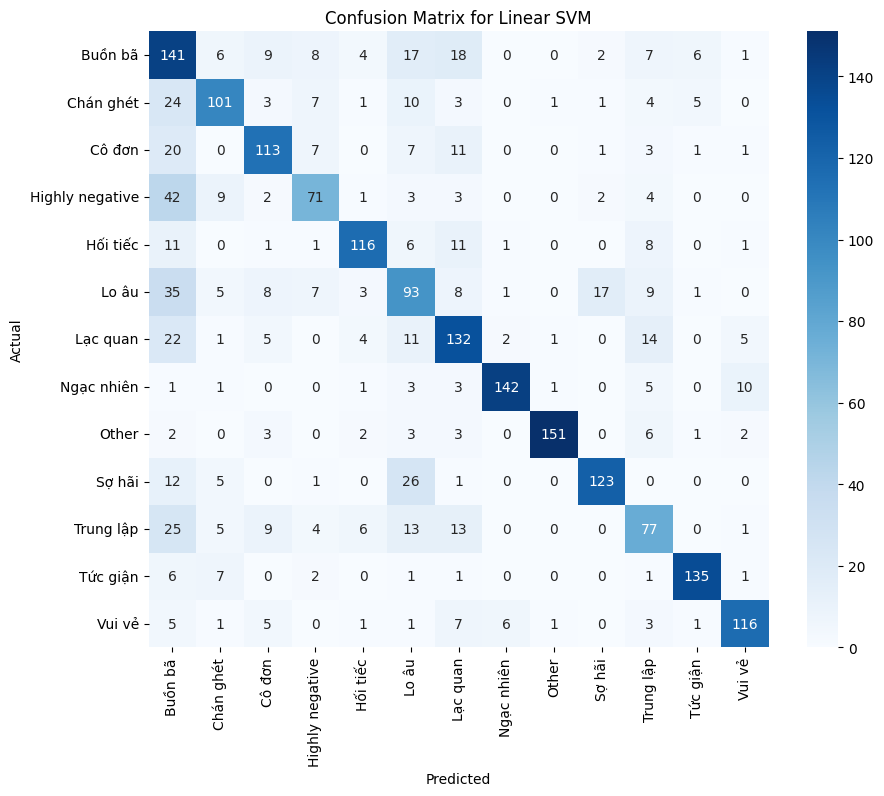


--- Training Multinomial Naive Bayes ---

Classification Report for Multinomial Naive Bayes:
                 precision    recall  f1-score   support

        Buồn bã       0.36      0.73      0.48       219
      Chán ghét       0.78      0.62      0.69       160
         Cô đơn       0.72      0.66      0.69       164
Highly negative       0.75      0.42      0.54       137
       Hối tiếc       0.85      0.74      0.79       156
          Lo âu       0.45      0.46      0.46       187
       Lạc quan       0.54      0.71      0.61       197
     Ngạc nhiên       0.89      0.86      0.88       167
          Other       0.96      0.81      0.88       173
         Sợ hãi       0.86      0.72      0.78       168
      Trung lập       0.78      0.38      0.51       153
       Tức giận       0.88      0.83      0.85       154
         Vui vẻ       0.79      0.75      0.77       147

       accuracy                           0.67      2182
      macro avg       0.74      0.67      0.69   

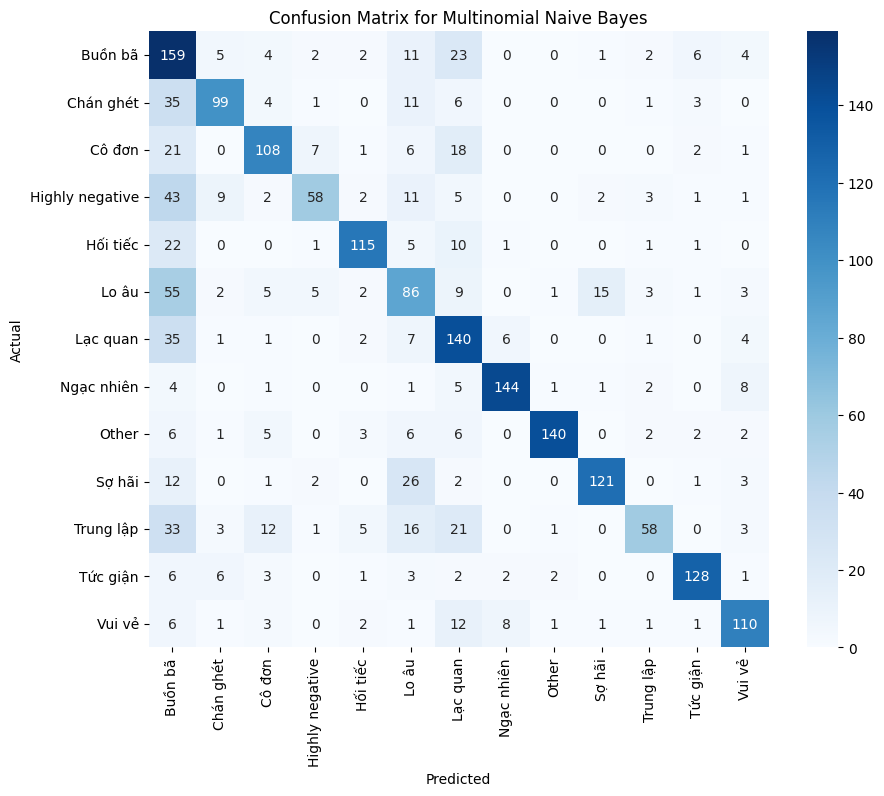


--- Training Decision Tree ---

Classification Report for Decision Tree:
                 precision    recall  f1-score   support

        Buồn bã       0.30      0.29      0.30       219
      Chán ghét       0.53      0.57      0.55       160
         Cô đơn       0.45      0.49      0.47       164
Highly negative       0.39      0.38      0.39       137
       Hối tiếc       0.65      0.62      0.64       156
          Lo âu       0.35      0.35      0.35       187
       Lạc quan       0.40      0.38      0.39       197
     Ngạc nhiên       0.86      0.79      0.82       167
          Other       0.78      0.80      0.79       173
         Sợ hãi       0.67      0.61      0.64       168
      Trung lập       0.32      0.35      0.34       153
       Tức giận       0.66      0.66      0.66       154
         Vui vẻ       0.59      0.64      0.62       147

       accuracy                           0.53      2182
      macro avg       0.53      0.53      0.53      2182
   weighted 

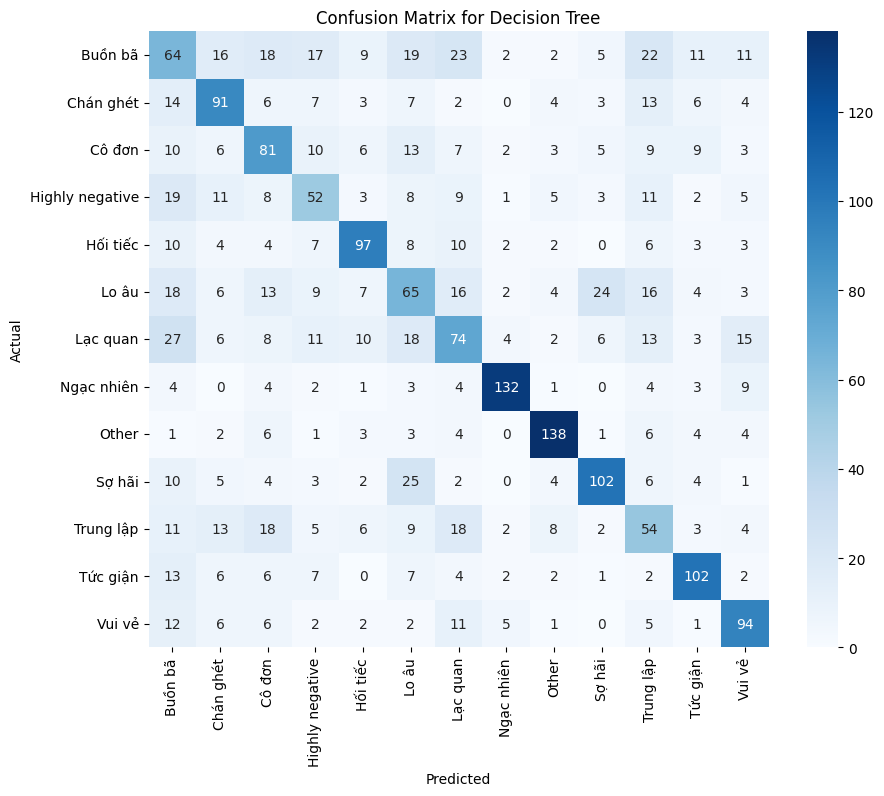


--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:50:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report for XGBoost:
                 precision    recall  f1-score   support

        Buồn bã       0.39      0.47      0.43       219
      Chán ghét       0.66      0.66      0.66       160
         Cô đơn       0.66      0.71      0.68       164
Highly negative       0.70      0.52      0.60       137
       Hối tiếc       0.77      0.72      0.74       156
          Lo âu       0.43      0.44      0.44       187
       Lạc quan       0.57      0.61      0.59       197
     Ngạc nhiên       0.91      0.83      0.87       167
          Other       0.91      0.86      0.89       173
         Sợ hãi       0.75      0.74      0.74       168
      Trung lập       0.47      0.45      0.46       153
       Tức giận       0.77      0.82      0.79       154
         Vui vẻ       0.81      0.78      0.79       147

       accuracy                           0.66      2182
      macro avg       0.68      0.66      0.67      2182
   weighted avg       0.67      0.66      0.66    

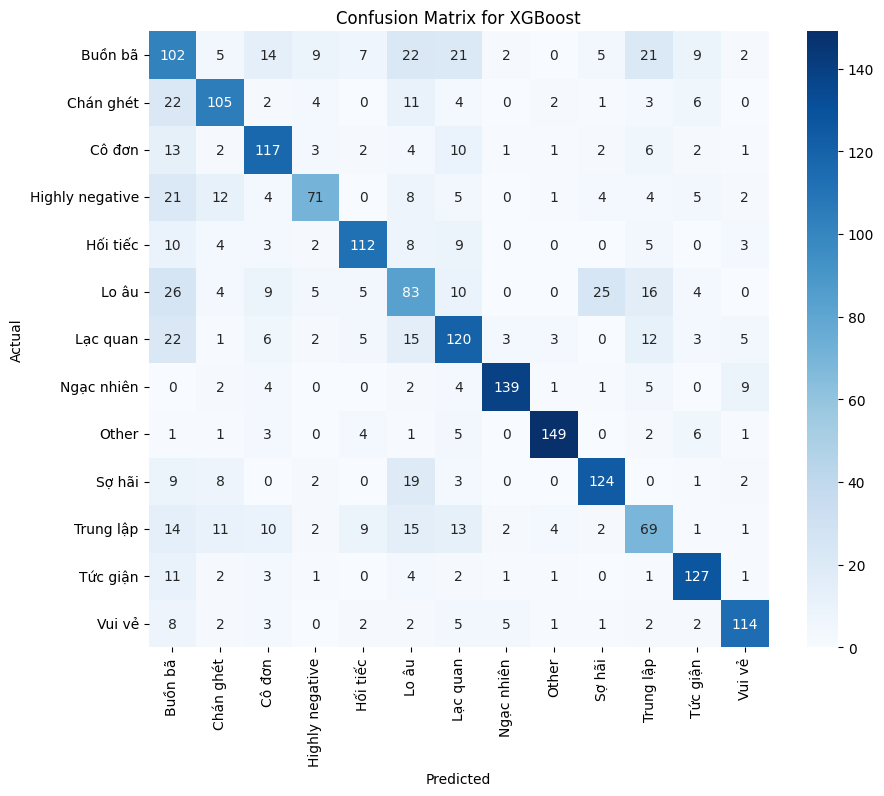

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get original labels for visualization
original_labels = le.inverse_transform(sorted(y.unique()))

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate model
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=original_labels, zero_division=0))

    print(f"Accuracy for {name}: {accuracy_score(y_test, y_pred):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=original_labels, yticklabels=original_labels)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

...

bpe.codes: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/273 [00:00<?, ?it/s]

Batches:   0%|          | 0/69 [00:00<?, ?it/s]

                 precision    recall  f1-score   support

        Buồn bã       0.46      0.53      0.49       219
      Chán ghét       0.73      0.72      0.73       160
         Cô đơn       0.67      0.71      0.69       164
Highly negative       0.59      0.50      0.55       137
       Hối tiếc       0.73      0.74      0.74       156
          Lo âu       0.52      0.56      0.54       187
       Lạc quan       0.65      0.69      0.67       197
     Ngạc nhiên       0.86      0.86      0.86       167
          Other       0.95      0.87      0.91       173
         Sợ hãi       0.82      0.76      0.79       168
      Trung lập       0.60      0.42      0.50       153
       Tức giận       0.86      0.93      0.89       154
         Vui vẻ       0.78      0.82      0.80       147

       accuracy                           0.70      2182
      macro avg       0.71      0.70      0.70      2182
   weighted avg       0.70      0.70      0.70      2182



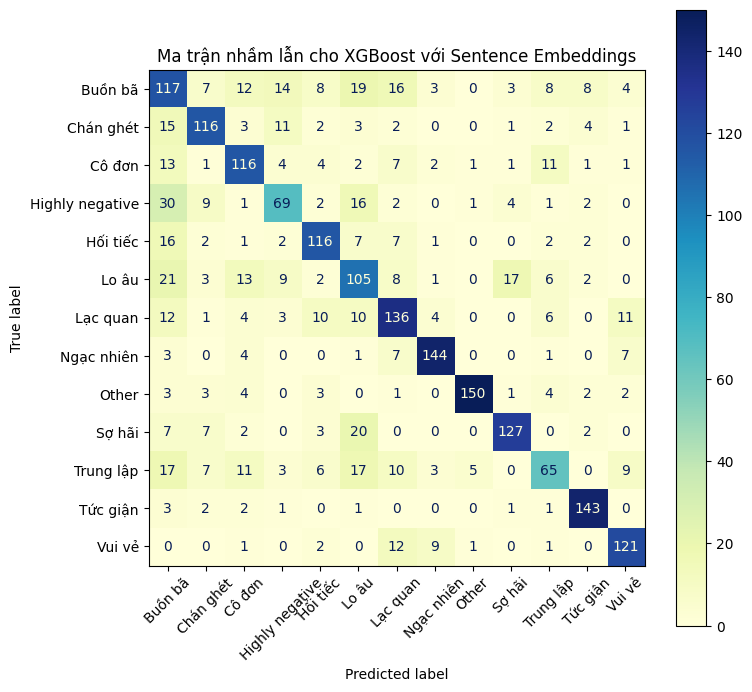

In [ ]:
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load model Embedding chuyên cho tiếng Việt
# 'paraphrase-multilingual-MiniLM-L12-v2' hoặc 'keepitreal/vietnamese-sbert'
embedder = SentenceTransformer('keepitreal/vietnamese-sbert')

# The previous X_train and X_test are TF-IDF sparse matrices.
# SentenceTransformer.encode() expects a list of strings (sentences).
# We need to get the original text corresponding to the train/test split.
# We will recreate the train/test split for the original text and labels.
# Ensure 'df_train' is available from previous cells.
# We use the same random_state=42 as the previous train_test_split to maintain consistency.
df_train_split_text, df_test_split_text, y_train_embed, y_test_embed = train_test_split(
    df['query_processed'], df['Emotion_encoded'], test_size=0.2, random_state=42
)

# 2. Biến câu thành Vector (Sẽ mất khoảng 1-2 phút tùy CPU/GPU)
# Now pass the actual list of strings to the embedder.
X_train_embed = embedder.encode(df_train_split_text.tolist(), show_progress_bar=True)
X_test_embed = embedder.encode(df_test_split_text.tolist(), show_progress_bar=True)

# 3. Train XGBoost trên nền Vector ngữ nghĩa
model_xgb_embed = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist' # Rất nhanh với 10k mẫu
)

model_xgb_embed.fit(X_train_embed, y_train_embed)

# 4. Kiểm tra kết quả
y_pred = model_xgb_embed.predict(X_test_embed)
print(classification_report(y_test_embed, y_pred, target_names=le.classes_))

con_matrix = confusion_matrix(y_test_embed, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=con_matrix, display_labels=le.classes_) # Added display_labels for better visualization
disp.plot(cmap='YlGnBu', ax=ax, xticks_rotation=45)
plt.title('Ma trận nhầm lẫn cho XGBoost với Sentence Embeddings') # Added title
plt.show()

# Label Groups

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/273 [00:00<?, ?it/s]

Batches:   0%|          | 0/69 [00:00<?, ?it/s]

               precision    recall  f1-score   support

        Anger       0.96      0.80      0.87       154
         Fear       0.90      0.67      0.77       168
 Negative_Sad       0.79      0.96      0.87      1023
Neutral_Other       0.95      0.63      0.76       326
     Positive       0.82      0.79      0.81       344
     Surprise       0.92      0.81      0.86       167

     accuracy                           0.84      2182
    macro avg       0.89      0.78      0.82      2182
 weighted avg       0.85      0.84      0.83      2182



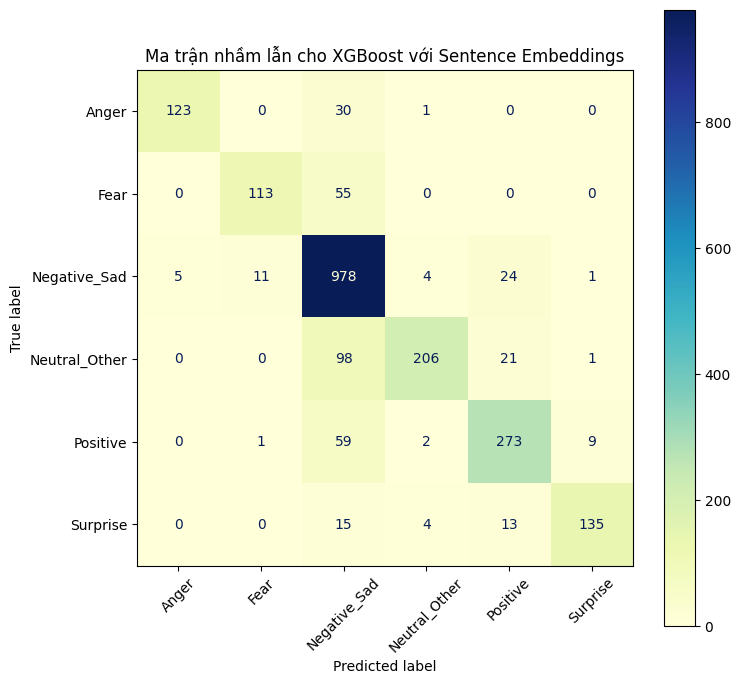

In [ ]:
label_groups = {
    'Buồn bã': 'Negative_Sad',
    'Chán ghét': 'Negative_Sad',
    'Cô đơn': 'Negative_Sad',
    'Hối tiếc': 'Negative_Sad',
    'Lo âu': 'Negative_Sad',
    'Highly negative': 'Negative_Sad',
    'Vui vẻ': 'Positive',
    'Lạc quan': 'Positive',
    'Ngạc nhiên': 'Surprise',
    'Tức giận': 'Anger',
    'Sợ hãi': 'Fear',
    'Trung lập': 'Neutral_Other',
    'Other': 'Neutral_Other'
}

df["emotion_groupped"] = df["Emotion"].map(label_groups)

from sklearn.preprocessing import LabelEncoder
le_group = LabelEncoder()
df['emotion_groupped_encode'] = le_group.fit_transform(df['emotion_groupped'])

# 1. Load model Embedding chuyên cho tiếng Việt
# 'paraphrase-multilingual-MiniLM-L12-v2' hoặc 'keepitreal/vietnamese-sbert'
embedder = SentenceTransformer('keepitreal/vietnamese-sbert')

# The previous X_train and X_test are TF-IDF sparse matrices.
# SentenceTransformer.encode() expects a list of strings (sentences).
# We need to get the original text corresponding to the train/test split.
# We will recreate the train/test split for the original text and labels.
# Ensure 'df_train' is available from previous cells.
# We use the same random_state=42 as the previous train_test_split to maintain consistency.
df_train_split_text_group_emotion, df_test_split_text_group_emotion, y_train_embed_with_group_emotion, y_test_embed_with_group_emotion = train_test_split(
    df['query_processed'], df['emotion_groupped_encode'], test_size=0.2, random_state=42
)

# 2. Biến câu thành Vector (Sẽ mất khoảng 1-2 phút tùy CPU/GPU)
# Now pass the actual list of strings to the embedder.
X_train_embed_with_group_emotion = embedder.encode(df_train_split_text_group_emotion.tolist(), show_progress_bar=True)
X_test_embed_with_group_emotion = embedder.encode(df_test_split_text_group_emotion.tolist(), show_progress_bar=True)

# 3. Train XGBoost trên nền Vector ngữ nghĩa
model_xgb_embed = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist' # Rất nhanh với 10k mẫu
)

model_xgb_embed.fit(X_train_embed_with_group_emotion, y_train_embed_with_group_emotion)

# 4. Kiểm tra kết quả
y_pred = model_xgb_embed.predict(X_test_embed_with_group_emotion)
print(classification_report(y_test_embed_with_group_emotion, y_pred, target_names=le_group.classes_))

con_matrix = confusion_matrix(y_test_embed_with_group_emotion, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=con_matrix, display_labels=le_group.classes_) # Added display_labels for better visualization
disp.plot(cmap='YlGnBu', ax=ax, xticks_rotation=45)
plt.title('Ma trận nhầm lẫn cho XGBoost với Sentence Embeddings') # Added title
plt.show()

In [ ]:
import numpy as np

def predict_emotion(text, model, embedder, teencode_dict, label_encoder):
    # Bước 1: Tiền xử lý (Làm sạch & Dịch Teencode)
    # Tách từ để so khớp dictionary chính xác
    text_clean = text.lower().strip()
    words = text_clean.split()
    words = [teencode_dict.get(w, w) for w in words]
    text_clean = " ".join(words)

    # Bước 2: Tách từ tiếng Việt (Word Segmentation)
    # Quan trọng: Phải dùng cùng một thư viện đã dùng lúc Train (Underthesea)
    from underthesea import word_tokenize
    text_segmented = word_tokenize(text_clean, format="text")

    # Bước 3: Chuyển thành Semantic Embedding (Vector 768 chiều)
    # Lưu ý: encode nhận vào list nên ta bọc text trong []
    vector = embedder.encode([text_segmented])

    # Bước 4: Dự đoán bằng XGBoost
    pred_idx = model.predict(vector)[0]

    # Bước 5: Lấy xác suất (Confidence Score) để biết mô hình tự tin bao nhiêu %
    probs = model.predict_proba(vector)[0]
    confidence = np.max(probs)

    # Bước 6: Decode chỉ số thành tên nhãn (ví dụ: 0 -> 'Positive')
    label = label_encoder.inverse_transform([pred_idx])[0]

    return label, confidence

# --- TEST THỬ ---
raw_text = "sp này vcl luôn, mng nên mua nhaaa"
label, conf = predict_emotion(raw_text, model_xgb_embed, embedder, teencode_dict, le_group)

print(f"Câu gốc: {raw_text}")
print(f"Dự đoán: {label} (Độ tin cậy: {conf:.2%})")

Câu gốc: sp này vcl luôn, mng nên mua nhaaa
Dự đoán: Neutral_Other (Độ tin cậy: 71.35%)


In [ ]:
# Danh sách các nhóm cần soi chi tiết (Trừ các nhóm chỉ có 1 nhãn gốc)
target_groups = ['Anger', 'Fear', 'Negative_Sad', 'Neutral_Other', 'Positive', 'Surprise']
expert_models = {}
expert_encoders = {}

for group in target_groups:
    print(f"--- Đang huấn luyện chuyên gia cho nhóm: {group} ---")

    # 1. Lọc dữ liệu cho từng nhóm
    sub_labels = [label for label, g in label_groups.items() if g == group]
    df_sub = df[df['Emotion'].isin(sub_labels)].copy()

    # 2. Encode nhãn chi tiết
    le_sub = LabelEncoder()
    y_sub = le_sub.fit_transform(df_sub['Emotion'])

    # 3. Lấy Embedding (Dùng lại list đã encode trước đó để tiết kiệm thời gian)
    X_sub_embed = embedder.encode(df_sub['query_processed'].tolist(), show_progress_bar=True)

    # 4. Huấn luyện XGBoost chuyên gia
    model_sub = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        tree_method='hist'
    )
    model_sub.fit(X_sub_embed, y_sub)

    # 5. Lưu vào dictionary để dùng khi inference
    expert_models[group] = model_sub
    expert_encoders[group] = le_sub

--- Đang huấn luyện chuyên gia cho nhóm: Anger ---


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

--- Đang huấn luyện chuyên gia cho nhóm: Fear ---


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

--- Đang huấn luyện chuyên gia cho nhóm: Negative_Sad ---


...

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

--- Đang huấn luyện chuyên gia cho nhóm: Positive ---


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

--- Đang huấn luyện chuyên gia cho nhóm: Surprise ---


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
def predict_emotion_full_hierarchical(text, model_l1, expert_models, expert_encoders, embedder, teencode_dict, le_l1):
    # --- BƯỚC 1 & 2: TIỀN XỬ LÝ ---
    text_clean = text.lower().strip()
    words = text_clean.split()
    words = [teencode_dict.get(w, w) for w in words]
    text_clean = " ".join(words)
    text_segmented = word_tokenize(text_clean, format="text")

    # --- BƯỚC 3: EMBEDDING ---
    vector = embedder.encode([text_segmented])

    # --- BƯỚC 4: DỰ ĐOÁN TẦNG 1 (NHÓM LỚN) ---
    pred_l1_idx = model_l1.predict(vector)[0]
    label_l1 = le_l1.inverse_transform([pred_l1_idx])[0]

    probs_l1 = model_l1.predict_proba(vector)[0]
    conf_l1 = np.max(probs_l1)

    # --- BƯỚC 5: KIỂM TRA CHUYÊN GIA ---
    if label_l1 in expert_models:
        # Gọi chuyên gia tương ứng (ví dụ: Chuyên gia Positive)
        model_sub = expert_models[label_l1]
        le_sub = expert_encoders[label_l1]

        pred_sub_idx = model_sub.predict(vector)[0]
        label_detail = le_sub.inverse_transform([pred_sub_idx])[0]

        probs_sub = model_sub.predict_proba(vector)[0]
        conf_detail = np.max(probs_sub)

        return {
            "group": label_l1,
            "detail": label_detail,
            "confidence": conf_l1 * conf_detail,
            "is_detailed": True
        }

    # Trường hợp các nhóm đơn lẻ (Tức giận, Sợ hãi...)
    return {
        "group": label_l1,
        "detail": label_l1,
        "confidence": conf_l1,
        "is_detailed": False
    }

# --- TEST THỬ ---
test_queries = [
    "Hàng như cc", # Mong đợi: Positive -> Vui vẻ/Lạc quan
    "hàng như lol, tks shop",             # Mong đợi: Negative_Sad -> Highly negative
    "cho mình hỏi giá bao nhiêu ạ"        # Mong đợi: Neutral_Other -> Trung lập
]

for q in test_queries:
    res = predict_emotion_full_hierarchical(q, model_xgb_embed, expert_models, expert_encoders, embedder, teencode_dict, le_group)
    print(f"Câu: {q}")
    print(f"-> Nhóm: {res['group']} | Chi tiết: {res['detail']} ({res['confidence']:.2%})\n")

Câu: Hàng như cc
-> Nhóm: Negative_Sad | Chi tiết: Buồn bã (30.06%)

Câu: hàng như lol, tks shop
-> Nhóm: Neutral_Other | Chi tiết: Other (43.02%)

Câu: cho mình hỏi giá bao nhiêu ạ
-> Nhóm: Neutral_Other | Chi tiết: Other (93.29%)



In [ ]:
# Save model to .pkl
import joblib

# Tạo một dictionary chứa tất cả các thành phần cần thiết
model_bundle = {
    'model_l1': model_xgb_embed,              # Model tầng 1
    'expert_models': expert_models,          # Dictionary chứa các model chuyên gia
    'expert_encoders': expert_encoders,      # Dictionary chứa các encoder chuyên gia
    'le_l1': le_group,                       # LabelEncoder tầng 1
    'teencode_dict': teencode_dict,          # Từ điển teencode
}

# Lưu file
model_filename = 'emotion_hierarchical_model.joblib'
joblib.dump(model_bundle, model_filename)

print(f"✅ Đã lưu hệ thống mô hình vào file: {model_filename}")

✅ Đã lưu hệ thống mô hình vào file: emotion_hierarchical_model.joblib


In [ ]:
import joblib
import numpy as np
from underthesea import word_tokenize

# 1. Load bộ model bundle
loaded_bundle = joblib.load('/content/emotion_hierarchical_model.joblib')

# Trích xuất lại các thành phần
m_l1 = loaded_bundle['model_l1']
e_models = loaded_bundle['expert_models']
e_encoders = loaded_bundle['expert_encoders']
l_l1 = loaded_bundle['le_l1']
t_dict = loaded_bundle['teencode_dict']

# 2. Hàm Inference (Sử dụng các biến đã load)
def fast_inference(text, embedder):
    # Tiền xử lý nhanh
    text_clean = text.lower().strip()
    words = [t_dict.get(w, w) for w in text_clean.split()]
    text_segmented = word_tokenize(" ".join(words), format="text")

    # Vector hóa
    vector = embedder.encode([text_segmented])

    # Dự đoán Tầng 1
    pred_l1 = m_l1.predict(vector)[0]
    label_l1 = l_l1.inverse_transform([pred_l1])[0]

    # Kiểm tra chuyên gia
    if label_l1 in e_models:
        model_sub = e_models[label_l1]
        le_sub = e_encoders[label_l1]

        pred_sub = model_sub.predict(vector)[0]
        label_detail = le_sub.inverse_transform([pred_sub])[0]
        return label_l1, label_detail

    return label_l1, label_l1

# --- Chạy thử ---
# Lưu ý: embedder (SBERT) không lưu vào joblib vì nó rất nặng,
# bạn nên khởi tạo lại: embedder = SentenceTransformer('keepitreal/vietnamese-sbert')
print(fast_inference("Sản phẩm này chán vcl ra", embedder))

('Negative_Sad', 'Chán ghét')
